In [1]:
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import IPython.display as ipd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_df = pd.read_csv('data_path.csv')
train_df.head(5)

,command,path
0,back,data\person_1\BACK\000.wav
1,back,data\person_1\BACK\001.wav
2,back,data\person_1\BACK\002.wav
3,back,data\person_1\BACK\003.wav
4,back,data\person_1\BACK\004.wav


In [3]:
train_df["command"].unique()

array(['back', 'danger', 'next', 'pause', 'reset', 'start', 'stop'],
      dtype=object)

In [4]:
def noise(data):
    noise_amp = 0.1*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate = 0.8 , pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# taking any example and checking for techniques.
path = np.array(train_df.path)[1]
data, sample_rate = librosa.load(path)
print(sample_rate)

22050


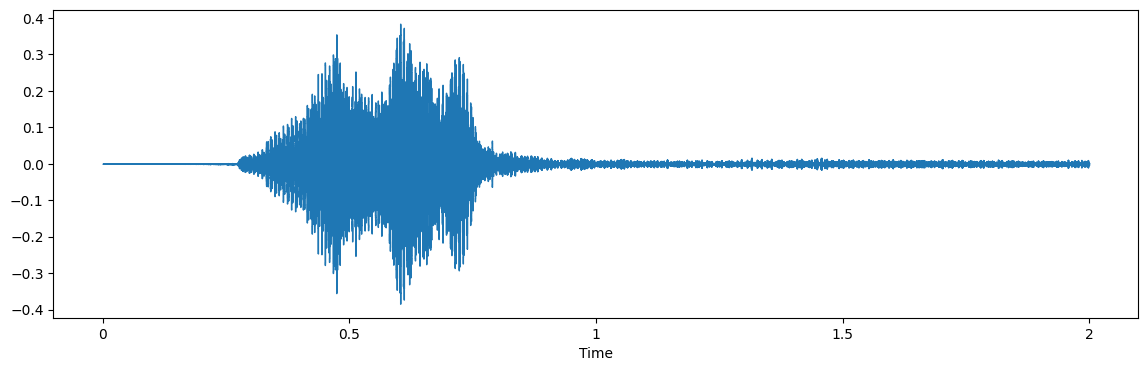

In [5]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
ipd.Audio(path)

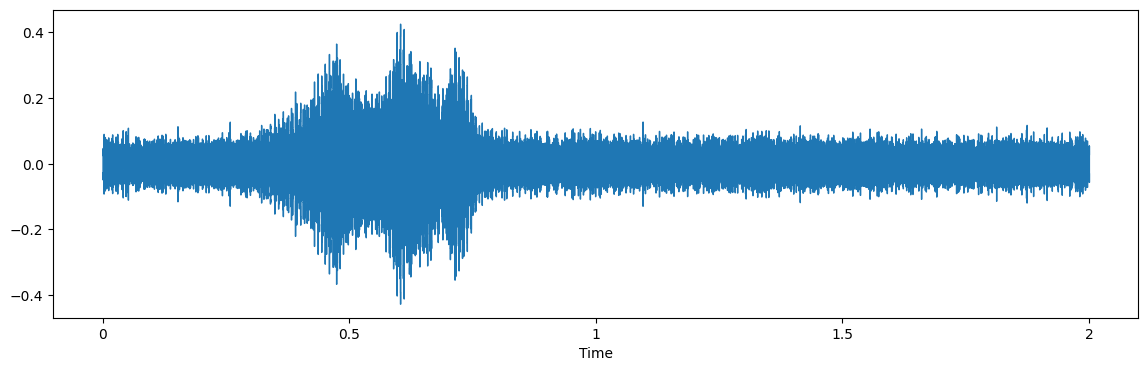

In [6]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
ipd.Audio(x, rate=sample_rate)

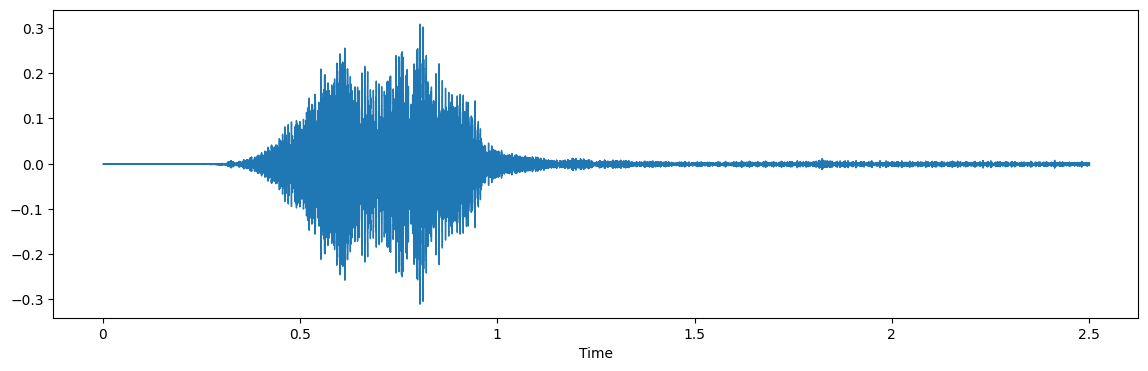

In [7]:
x = stretch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
ipd.Audio(x, rate=sample_rate)

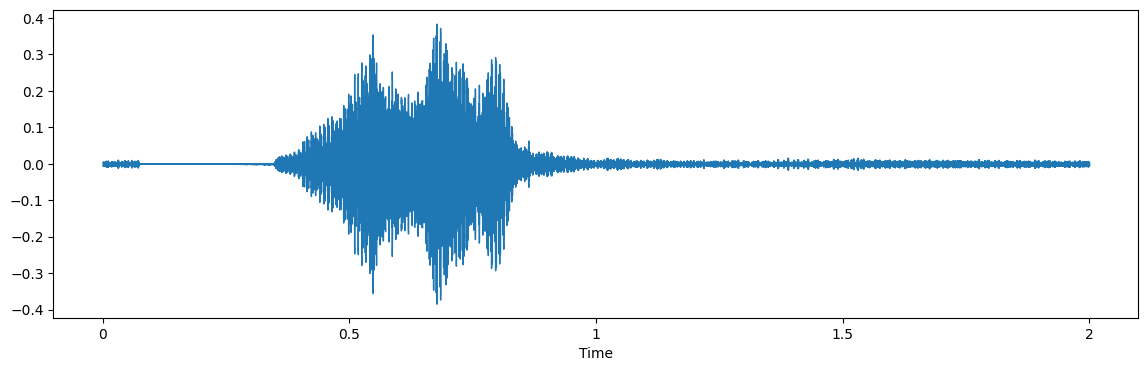

In [8]:
x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
ipd.Audio(x, rate=sample_rate)

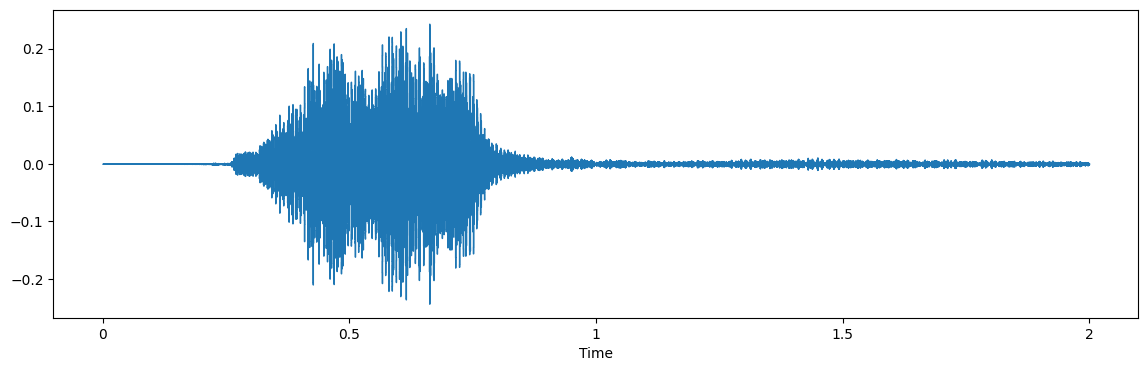

In [9]:
x = pitch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
ipd.Audio(x, rate=sample_rate)

In [10]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally
    
    return result

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=3, offset=0.6)
    
    # without augmentation
    res1 = extract_features(data)
    result = (res1)
    
    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    
    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically"""
    
    return result

In [11]:
X, Y = [], []
for path, command in zip(train_df.path, train_df.command):
    try:
        feature = get_features(path)
    except Exception as e:
        print(f"Error loading {path}: {e}")
#     print(feature)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(command)

In [12]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head(10)

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.054175,0.765858,0.794722,0.942506,0.798499,0.627610,0.646994,0.765119,0.741286,0.642675,...,0.000103,0.000135,0.000261,0.000398,0.000374,0.000099,0.000059,0.000073,7.190153e-05,back
1,0.427766,0.862514,0.880725,0.933875,0.953346,0.886314,0.780683,0.770374,0.771063,0.772270,...,0.050448,0.049505,0.051125,0.053915,0.049198,0.050056,0.049748,0.050922,5.136019e-02,back
2,0.049747,0.683394,0.702293,0.750839,0.910117,0.803374,0.521431,0.512736,0.676822,0.728059,...,0.000044,0.000056,0.000045,0.000090,0.000127,0.000212,0.000100,0.000014,1.815067e-06,back
3,0.036613,0.700524,0.772193,0.931898,0.774287,0.655159,0.663269,0.794247,0.783549,0.658294,...,0.000044,0.000048,0.000118,0.000335,0.000708,0.000316,0.000055,0.000069,5.721186e-05,back
4,0.429199,0.831188,0.856043,0.889625,0.943816,0.921748,0.861405,0.783668,0.772103,0.748597,...,0.045549,0.043064,0.043870,0.042926,0.042348,0.044231,0.045779,0.044138,4.544068e-02,back
5,0.037026,0.834248,0.791021,0.723019,0.722855,0.750186,0.624915,0.683550,0.787782,0.852190,...,0.000024,0.000029,0.000021,0.000033,0.000078,0.000296,0.000283,0.000045,1.750623e-06,back
6,0.028352,0.763799,0.844452,0.984624,0.792207,0.673373,0.654059,0.792587,0.869797,0.750191,...,0.000016,0.000012,0.000019,0.000026,0.000018,0.000010,0.000007,0.000009,7.549776e-06,back
7,0.076196,0.776401,0.853822,0.992196,0.856321,0.744786,0.687330,0.760409,0.848925,0.776659,...,0.000078,0.000076,0.000081,0.000097,0.000087,0.000074,0.000073,0.000076,7.153478e-05,back
8,0.021722,0.580562,0.591290,0.764433,0.968760,0.760112,0.507124,0.548965,0.674245,0.891085,...,0.000010,0.000014,0.000007,0.000010,0.000016,0.000016,0.000009,0.000002,1.848431e-07,back
9,0.049789,0.713371,0.810646,0.926010,0.744422,0.633192,0.656970,0.719480,0.753270,0.668999,...,0.000842,0.000830,0.002561,0.002728,0.002804,0.001060,0.000369,0.001316,1.088370e-03,back


In [13]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values

In [14]:
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((315, 162), (315, 7), (105, 162), (105, 7))

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [17]:
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((315, 162, 1), (315, 7), (105, 162, 1), (105, 7))

In [18]:
class audio_model(nn.Module):
    def __init__(self, input_features=162, num_classes=7):
        super(audio_model, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Блок 1
            nn.Conv1d(1, 32, kernel_size=3, padding=1),  # (N, 32, 162)
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),  # (N, 32, 81)
            nn.Dropout(0.1),
            
            # Блок 2
            nn.Conv1d(32, 64, kernel_size=3, padding=1),  # (N, 64, 81)
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),  # (N, 64, 40)
            nn.Dropout(0.1),
            
            # Блок 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),  # (N, 128, 40)
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),  # (N, 128, 20)
            nn.Dropout(0.1),
        )
        
        # После 3 MaxPool(2): 162 // 8 = 20
        self.flattened_size = 128 * 20
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x


model = audio_model(input_features=162, num_classes=7)

print(model)

audio_model(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.1, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.1, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1,

In [19]:
class EarlyStopping:
    def __init__(self, patience=10, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = float('inf')
        self.best_weights = None

    def __call__(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
                return True
        return False



y_train_labels = y_train.argmax(1)  # (315, 7) → (315,)
y_test_labels = y_test.argmax(1)    # (105, 7) → (105,)

x_train_tensor = torch.FloatTensor(x_train)
y_train_tensor = torch.LongTensor(y_train_labels)
x_test_tensor = torch.FloatTensor(x_test)
y_test_tensor = torch.LongTensor(y_test_labels)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

model = audio_model(input_features=162, num_classes=7)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
early_stopping = EarlyStopping(patience=10)

In [20]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(100):
    # Обучение
    model.train()
    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    # Сохраняем метрики обучения
    train_loss = epoch_train_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    model.eval()
    epoch_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    # Сохраняем метрики валидации
    val_loss = epoch_val_loss / len(test_loader.dataset)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Обновление LR и проверка ранней остановки
    scheduler.step(val_loss)
    if early_stopping(model, val_loss):
        print(f"Early stopping triggered at epoch {epoch}")
        break
    
    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

# После обучения восстанавливаем лучшие веса
model.load_state_dict(early_stopping.best_weights)

Epoch 1 | Train Loss: 1.8475 Acc: 0.2698 | Val Loss: 1.7613 Acc: 0.4381 | LR: 0.001000
Epoch 2 | Train Loss: 1.4215 Acc: 0.4762 | Val Loss: 1.3116 Acc: 0.6381 | LR: 0.001000
Epoch 3 | Train Loss: 1.0441 Acc: 0.6857 | Val Loss: 0.9531 Acc: 0.7905 | LR: 0.001000
Epoch 4 | Train Loss: 0.8644 Acc: 0.7143 | Val Loss: 0.7365 Acc: 0.7905 | LR: 0.001000
Epoch 5 | Train Loss: 0.6563 Acc: 0.7746 | Val Loss: 0.5612 Acc: 0.8667 | LR: 0.001000
Epoch 6 | Train Loss: 0.5410 Acc: 0.8381 | Val Loss: 0.4638 Acc: 0.8667 | LR: 0.001000
Epoch 7 | Train Loss: 0.4597 Acc: 0.8571 | Val Loss: 0.3857 Acc: 0.8667 | LR: 0.001000
Epoch 8 | Train Loss: 0.3871 Acc: 0.8794 | Val Loss: 0.3416 Acc: 0.9143 | LR: 0.001000
Epoch 9 | Train Loss: 0.3211 Acc: 0.9111 | Val Loss: 0.3197 Acc: 0.8762 | LR: 0.001000
Epoch 10 | Train Loss: 0.3095 Acc: 0.9016 | Val Loss: 0.2844 Acc: 0.8952 | LR: 0.001000
Epoch 11 | Train Loss: 0.2537 Acc: 0.9270 | Val Loss: 0.2561 Acc: 0.8857 | LR: 0.001000
Epoch 12 | Train Loss: 0.2075 Acc: 0.9460

<All keys matched successfully>

Accuracy: 96.19%


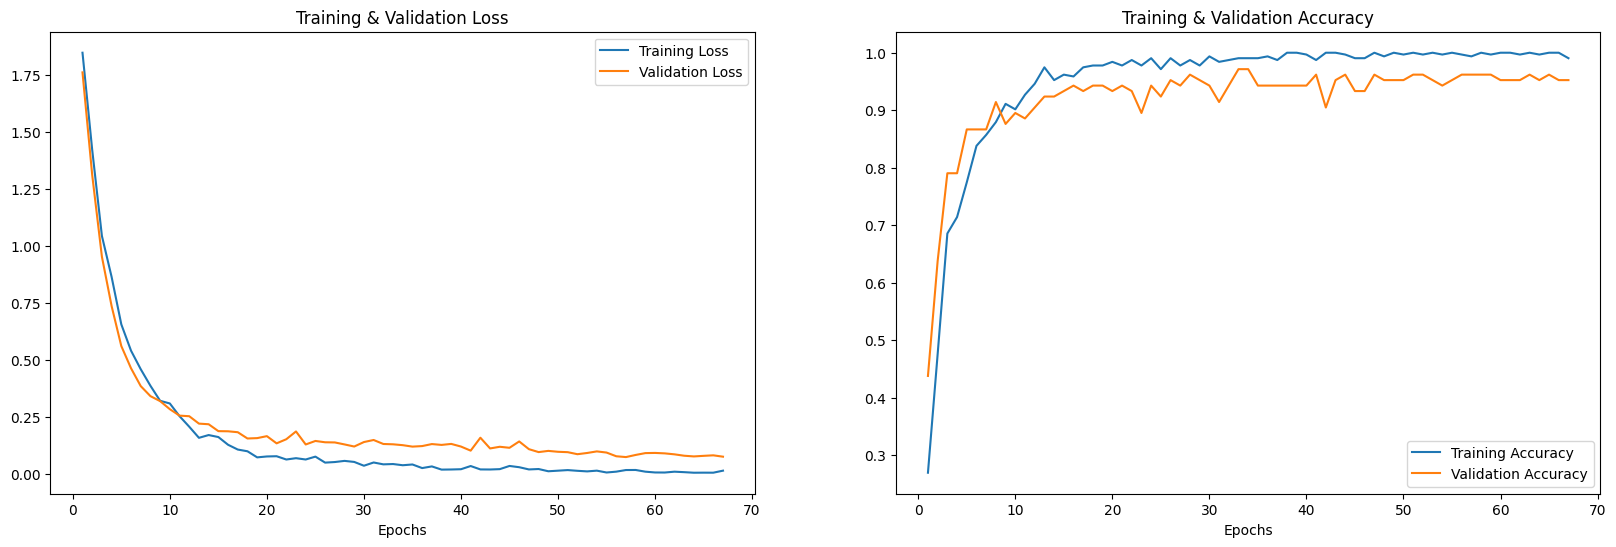

In [21]:
# 1. Оценка модели на тестовых данных
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader.dataset)
test_acc = correct / total
print(f"Accuracy: {test_acc*100:.2f}%")

# 2. Визуализация истории обучения
epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# График потерь
ax[0].plot(epochs, train_losses, label='Training Loss')
ax[0].plot(epochs, val_losses, label='Validation Loss')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# График точности
ax[1].plot(epochs, train_accs, label='Training Accuracy')
ax[1].plot(epochs, val_accs, label='Validation Accuracy')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

In [22]:
# Предсказание на тестовых данных
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Создаем one-hot представление из индексов
def indices_to_onehot(indices, num_classes):
    onehot = np.zeros((len(indices), num_classes))
    onehot[np.arange(len(indices)), indices] = 1
    return onehot

# Преобразование предсказаний и меток
y_pred_onehot = indices_to_onehot(all_preds, num_classes=7)
y_test_onehot = indices_to_onehot(all_labels, num_classes=7)

# Теперь преобразуем обратно в исходные метки
y_pred = encoder.inverse_transform(y_pred_onehot)
y_test_original = encoder.inverse_transform(y_test_onehot)

In [23]:
df = pd.DataFrame(columns=['Предсказанные метки', 'Реальные метки'])
df['Предсказанные метки'] = y_pred.flatten()
df['Реальные метки'] = y_test_original.flatten()

df.head(10)

,Предсказанные метки,Реальные метки
0,next,next
1,start,start
2,back,back
3,danger,danger
4,next,next
5,next,next
6,back,back
7,reset,reset
8,pause,pause
9,start,start


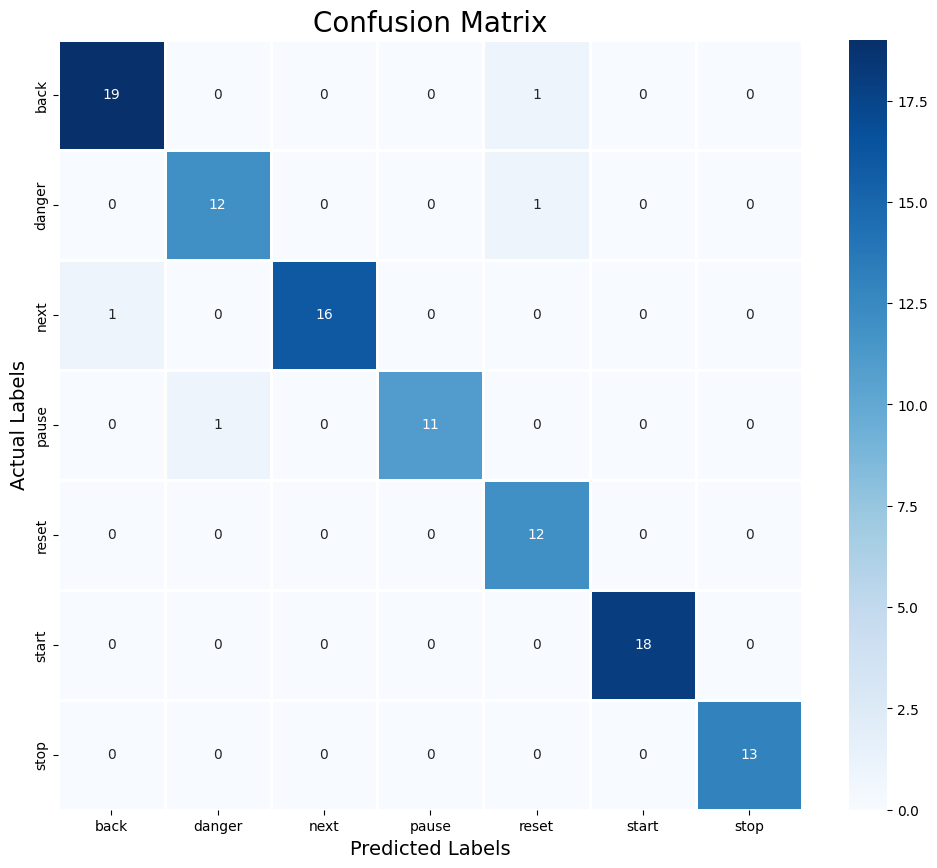

In [24]:
cm = confusion_matrix(y_test_original, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [25]:
print(classification_report(y_test_original, y_pred))

              precision    recall  f1-score   support

        back       0.95      0.95      0.95        20
      danger       0.92      0.92      0.92        13
        next       1.00      0.94      0.97        17
       pause       1.00      0.92      0.96        12
       reset       0.86      1.00      0.92        12
       start       1.00      1.00      1.00        18
        stop       1.00      1.00      1.00        13

    accuracy                           0.96       105
   macro avg       0.96      0.96      0.96       105
weighted avg       0.96      0.96      0.96       105



In [26]:
torch.save(model.state_dict(), 'model_pytorch_only_weights.pt')
torch.save(model, 'model_pytorch.pt')